<a href="https://colab.research.google.com/github/Shubhalaxmi-Sahu/student-performance-analysis/blob/main/Continuous_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu

Training for 2000 epochs ...

Epoch     1 | Total=1.1977e+00 | IC=1.1851e+00 | BC=9.5716e-03 | PDE=3.0469e-03
Epoch   200 | Total=6.7827e-02 | IC=3.4916e-02 | BC=6.4698e-05 | PDE=3.2846e-02
Epoch   400 | Total=5.5692e-02 | IC=2.3850e-02 | BC=1.6144e-05 | PDE=3.1825e-02
Epoch   600 | Total=4.7472e-02 | IC=1.8611e-02 | BC=1.4474e-05 | PDE=2.8846e-02
Epoch   800 | Total=4.0351e-02 | IC=1.5173e-02 | BC=2.0183e-04 | PDE=2.4976e-02
Epoch  1000 | Total=3.7631e-02 | IC=1.3513e-02 | BC=8.6892e-05 | PDE=2.4031e-02
Epoch  1200 | Total=3.1427e-02 | IC=1.0723e-02 | BC=8.1787e-06 | PDE=2.0696e-02
Epoch  1400 | Total=2.6681e-02 | IC=8.4546e-03 | BC=1.2741e-05 | PDE=1.8214e-02
Epoch  1600 | Total=2.2544e-02 | IC=5.8785e-03 | BC=1.6044e-03 | PDE=1.5061e-02
Epoch  1800 | Total=1.5372e-02 | IC=3.4049e-03 | BC=6.6957e-06 | PDE=1.1960e-02
Epoch  2000 | Total=1.1727e-02 | IC=2.6161e-03 | BC=1.2803e-05 | PDE=9.0984e-03

Training complete!


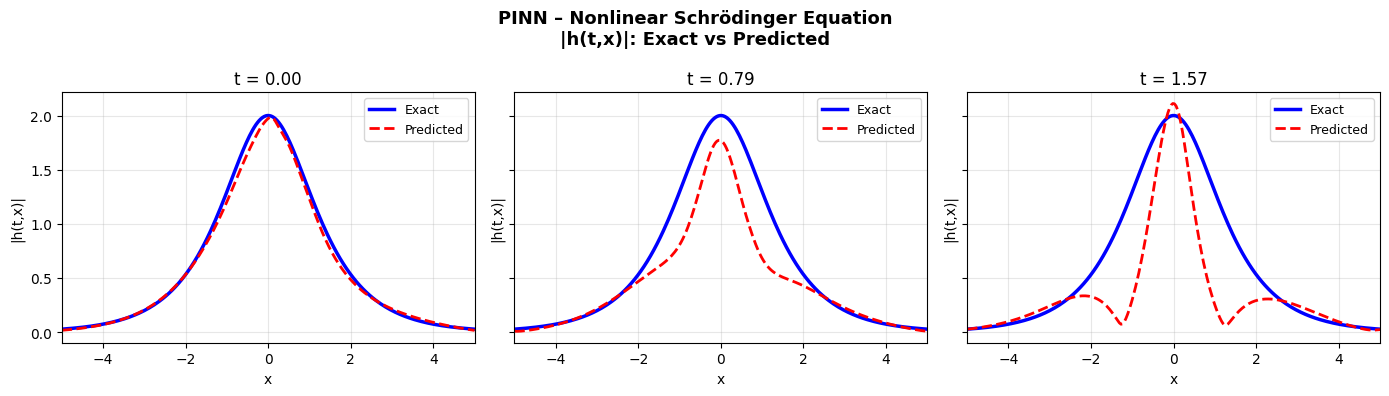

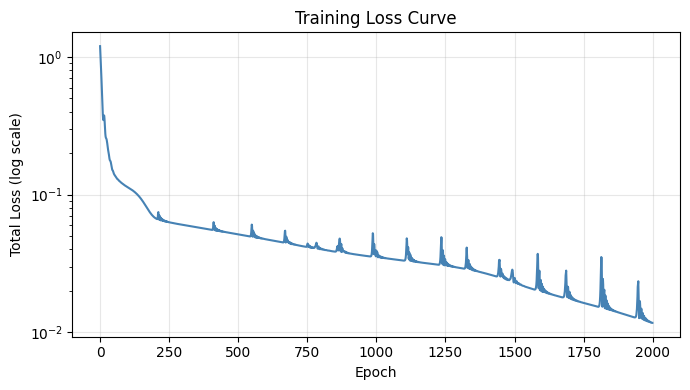


Plots saved to /mnt/user-data/outputs/


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os # Import the os module

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_ic   = 50    # initial-condition points
N_bc   = 30    # boundary points
N_col  = 500   # collocation (PDE) points
EPOCHS = 2000
LR     = 1e-3

# ── Neural Network ───────────────────────────────────────────────────────────
class PINN(nn.Module):
    """Outputs [u, v] = [Re(h), Im(h)]"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)          # output: [u, v]
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)           # shape (N, 2)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── Helper to compute gradients ───────────────────────────────────────────────
def grad(y, x):
    return torch.autograd.grad(y, x,
                               grad_outputs=torch.ones_like(y),
                               create_graph=True)[0]

# ── Training data ─────────────────────────────────────────────────────────────

# 1) Initial condition  h(0, x) = 2*sech(x)  →  u=2sech(x), v=0
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-5, 5).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic_true = 2.0 / torch.cosh(x_ic)          # Re(h)
v_ic_true = torch.zeros_like(x_ic)           # Im(h)

# 2) Periodic boundary h(t,-5)=h(t,5)
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, np.pi / 2).to(device)
x_left  = -5 * torch.ones(N_bc, 1).to(device)
x_right =  5 * torch.ones(N_bc, 1).to(device)

# 3) Collocation points inside domain
x_col = torch.FloatTensor(N_col, 1).uniform_(-5, 5).to(device).requires_grad_(True)
t_col = torch.FloatTensor(N_col, 1).uniform_(0, np.pi / 2).to(device).requires_grad_(True)

# ── Loss function ─────────────────────────────────────────────────────────────
def compute_loss():
    # --- IC loss ---
    uv_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((uv_ic[:, 0:1] - u_ic_true) ** 2 +
                         (uv_ic[:, 1:2] - v_ic_true) ** 2)

    # --- Periodic BC loss ---
    uv_l = model(x_left,  t_bc)
    uv_r = model(x_right, t_bc)
    loss_bc = torch.mean((uv_l - uv_r) ** 2)

    # --- PDE residual loss ---
    uv = model(x_col, t_col)
    u, v = uv[:, 0:1], uv[:, 1:2]

    u_t  = grad(u, t_col);  v_t  = grad(v, t_col)
    u_x  = grad(u, x_col);  v_x  = grad(v, x_col)
    u_xx = grad(u_x, x_col); v_xx = grad(v_x, x_col)

    h2 = u ** 2 + v ** 2          # |h|^2

    # i*h_t + 0.5*h_xx + |h|^2*h = 0
    # Real part: -v_t + 0.5*u_xx + h2*u = 0
    # Imag part:  u_t + 0.5*v_xx + h2*v = 0
    f_u = -v_t + 0.5 * u_xx + h2 * u
    f_v =  u_t + 0.5 * v_xx + h2 * v

    loss_pde = torch.mean(f_u ** 2 + f_v ** 2)

    return loss_ic + loss_bc + loss_pde, loss_ic, loss_bc, loss_pde

# ── Training loop ─────────────────────────────────────────────────────────────
loss_history = []
print(f"\nTraining for {EPOCHS} epochs ...\n")

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    loss, l_ic, l_bc, l_pde = compute_loss()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Total={loss.item():.4e} | "
              f"IC={l_ic.item():.4e} | BC={l_bc.item():.4e} | PDE={l_pde.item():.4e}")

print("\nTraining complete!")

# Ensure output directory exists
output_dir = "/mnt/user-data/outputs/"
os.makedirs(output_dir, exist_ok=True)

# ── Prediction & Exact solution ───────────────────────────────────────────────
x_test = np.linspace(-5, 5, 256)

# Exact |h(t,x)| = 2*sech(x) * exp(i*t)  →  |h| = 2/cosh(x)  (constant envelope)
def exact_h(t_val, x_arr):
    return 2.0 / np.cosh(x_arr)          # amplitude independent of t

t_vals = [0.0, np.pi / 4, np.pi / 2]    # three time slices

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("PINN – Nonlinear Schrödinger Equation\n|h(t,x)|: Exact vs Predicted",
             fontsize=13, fontweight="bold")

model.eval()
with torch.no_grad():
    for ax, t_val in zip(axes, t_vals):
        x_t = torch.FloatTensor(x_test[:, None]).to(device)
        t_t = t_val * torch.ones_like(x_t)
        uv  = model(x_t, t_t).cpu().numpy()
        h_pred = np.sqrt(uv[:, 0] ** 2 + uv[:, 1] ** 2)
        h_exact = exact_h(t_val, x_test)

        ax.plot(x_test, h_exact, "b-",  lw=2.5, label="Exact")
        ax.plot(x_test, h_pred,  "r--", lw=2,   label="Predicted")
        ax.set_title(f"t = {t_val:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("|h(t,x)|")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 5)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pinn_results.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Loss curve ────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.semilogy(loss_history, color="steelblue", lw=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Total Loss (log scale)")
ax2.set_title("Training Loss Curve")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nPlots saved to /mnt/user-data/outputs/")

Using device: cpu

Training for 1000 epochs ...

Epoch     1 | Total=1.19772756 | IC=1.18510902 | BC=0.00957160 | PDE=0.00304694
Epoch   200 | Total=0.06782740 | IC=0.03491633 | BC=0.00006470 | PDE=0.03284637
Epoch   400 | Total=0.05569196 | IC=0.02385045 | BC=0.00001614 | PDE=0.03182537
Epoch   600 | Total=0.04747180 | IC=0.01861108 | BC=0.00001447 | PDE=0.02884624
Epoch   800 | Total=0.04035086 | IC=0.01517339 | BC=0.00020183 | PDE=0.02497564
Epoch  1000 | Total=0.03763147 | IC=0.01351322 | BC=0.00008689 | PDE=0.02403136

Training complete!


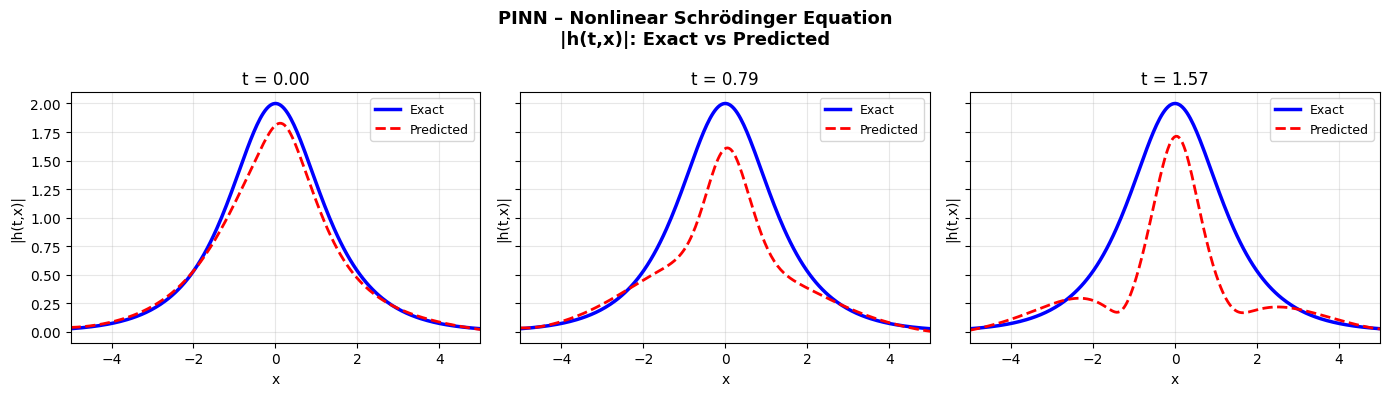

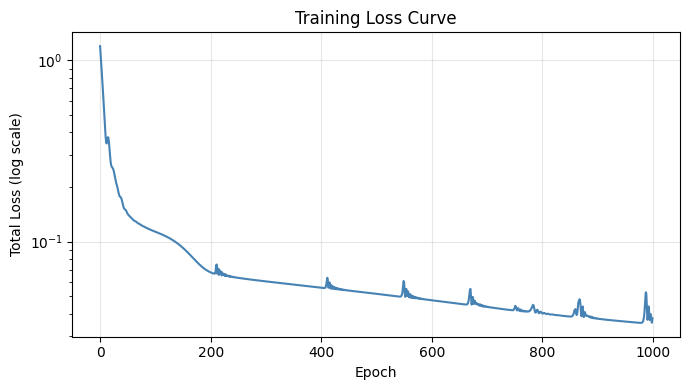

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_ic   = 50    # initial-condition points
N_bc   = 30    # boundary points
N_col  = 500   # collocation (PDE) points
EPOCHS = 1000
LR     = 1e-3

# ── Neural Network ───────────────────────────────────────────────────────────
class PINN(nn.Module):
    """Outputs [u, v] = [Re(h), Im(h)]"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)          # output: [u, v]
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)           # shape (N, 2)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── Helper to compute gradients ───────────────────────────────────────────────
def grad(y, x):
    return torch.autograd.grad(y, x,
                               grad_outputs=torch.ones_like(y),
                               create_graph=True)[0]

# ── Training data ─────────────────────────────────────────────────────────────

# 1) Initial condition  h(0, x) = 2*sech(x)  →  u=2sech(x), v=0
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-5, 5).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic_true = 2.0 / torch.cosh(x_ic)          # Re(h)
v_ic_true = torch.zeros_like(x_ic)           # Im(h)

# 2) Periodic boundary h(t,-5)=h(t,5)
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, np.pi / 2).to(device)
x_left  = -5 * torch.ones(N_bc, 1).to(device)
x_right =  5 * torch.ones(N_bc, 1).to(device)

# 3) Collocation points inside domain
x_col = torch.FloatTensor(N_col, 1).uniform_(-5, 5).to(device).requires_grad_(True)
t_col = torch.FloatTensor(N_col, 1).uniform_(0, np.pi / 2).to(device).requires_grad_(True)

# ── Loss function ─────────────────────────────────────────────────────────────
def compute_loss():
    # --- IC loss ---
    uv_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((uv_ic[:, 0:1] - u_ic_true) ** 2 +
                         (uv_ic[:, 1:2] - v_ic_true) ** 2)

    # --- Periodic BC loss ---
    uv_l = model(x_left,  t_bc)
    uv_r = model(x_right, t_bc)
    loss_bc = torch.mean((uv_l - uv_r) ** 2)

    # --- PDE residual loss ---
    uv = model(x_col, t_col)
    u, v = uv[:, 0:1], uv[:, 1:2]

    u_t  = grad(u, t_col);  v_t  = grad(v, t_col)
    u_x  = grad(u, x_col);  v_x  = grad(v, x_col)
    u_xx = grad(u_x, x_col); v_xx = grad(v_x, x_col)

    h2 = u ** 2 + v ** 2          # |h|^2

    # i*h_t + 0.5*h_xx + |h|^2*h = 0
    # Real part: -v_t + 0.5*u_xx + h2*u = 0
    # Imag part:  u_t + 0.5*v_xx + h2*v = 0
    f_u = -v_t + 0.5 * u_xx + h2 * u
    f_v =  u_t + 0.5 * v_xx + h2 * v

    loss_pde = torch.mean(f_u ** 2 + f_v ** 2)

    return loss_ic + loss_bc + loss_pde, loss_ic, loss_bc, loss_pde

# ── Training loop ─────────────────────────────────────────────────────────────
loss_history = []
print(f"\nTraining for {EPOCHS} epochs ...\n")

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    loss, l_ic, l_bc, l_pde = compute_loss()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Total={loss.item():.8f} | "
              f"IC={l_ic.item():.8f} | BC={l_bc.item():.8f} | PDE={l_pde.item():.8f}")

print("\nTraining complete!")

# ── Prediction & Exact solution ───────────────────────────────────────────────
x_test = np.linspace(-5, 5, 256)

# Exact |h(t,x)| = 2*sech(x) * exp(i*t)  →  |h| = 2/cosh(x)  (constant envelope)
def exact_h(t_val, x_arr):
    return 2.0 / np.cosh(x_arr)          # amplitude independent of t

t_vals = [0.0, np.pi / 4, np.pi / 2]    # three time slices

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("PINN – Nonlinear Schrödinger Equation\n|h(t,x)|: Exact vs Predicted",
             fontsize=13, fontweight="bold")

model.eval()
with torch.no_grad():
    for ax, t_val in zip(axes, t_vals):
        x_t = torch.FloatTensor(x_test[:, None]).to(device)
        t_t = t_val * torch.ones_like(x_t)
        uv  = model(x_t, t_t).cpu().numpy()
        h_pred = np.sqrt(uv[:, 0] ** 2 + uv[:, 1] ** 2)
        h_exact = exact_h(t_val, x_test)

        ax.plot(x_test, h_exact, "b-",  lw=2.5, label="Exact")
        ax.plot(x_test, h_pred,  "r--", lw=2,   label="Predicted")
        ax.set_title(f"t = {t_val:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("|h(t,x)|")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 5)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/pinn_results.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Loss curve ────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.semilogy(loss_history, color="steelblue", lw=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Total Loss (log scale)")
ax2.set_title("Training Loss Curve")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

#print("\nPlots saved to /mnt/user-data/outputs/")

Using device: cpu

Training for 5000 epochs ...

Epoch     1 | Total=1.1977e+00 | IC=1.1851e+00 | BC=9.5716e-03 | PDE=3.0469e-03
Epoch   500 | Total=5.1540e-02 | IC=2.1082e-02 | BC=8.7229e-06 | PDE=3.0449e-02
Epoch  1000 | Total=3.7631e-02 | IC=1.3513e-02 | BC=8.6892e-05 | PDE=2.4031e-02
Epoch  1500 | Total=2.4067e-02 | IC=6.8637e-03 | BC=8.0929e-04 | PDE=1.6394e-02
Epoch  2000 | Total=1.1727e-02 | IC=2.6161e-03 | BC=1.2803e-05 | PDE=9.0984e-03
Epoch  2500 | Total=7.8595e-03 | IC=2.1467e-03 | BC=8.9662e-04 | PDE=4.8162e-03
Epoch  3000 | Total=3.7625e-03 | IC=1.0137e-03 | BC=8.1288e-05 | PDE=2.6675e-03
Epoch  3500 | Total=2.5761e-03 | IC=6.7826e-04 | BC=1.9009e-04 | PDE=1.7078e-03
Epoch  4000 | Total=1.7165e-03 | IC=3.8644e-04 | BC=1.3837e-04 | PDE=1.1917e-03
Epoch  4500 | Total=1.0901e-03 | IC=2.2235e-04 | BC=1.3610e-05 | PDE=8.5414e-04
Epoch  5000 | Total=8.4225e-04 | IC=1.7121e-04 | BC=1.1763e-05 | PDE=6.5927e-04

Training complete!


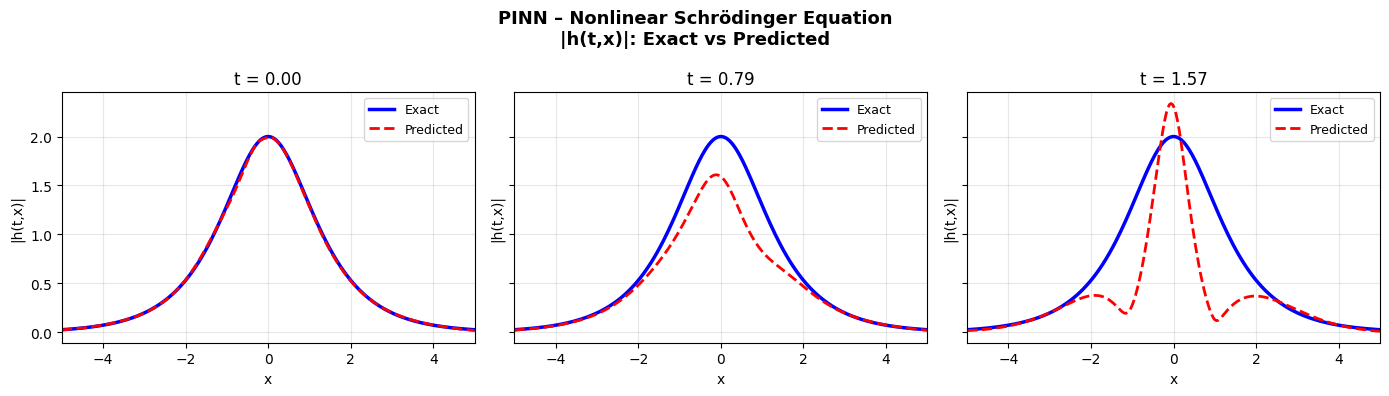

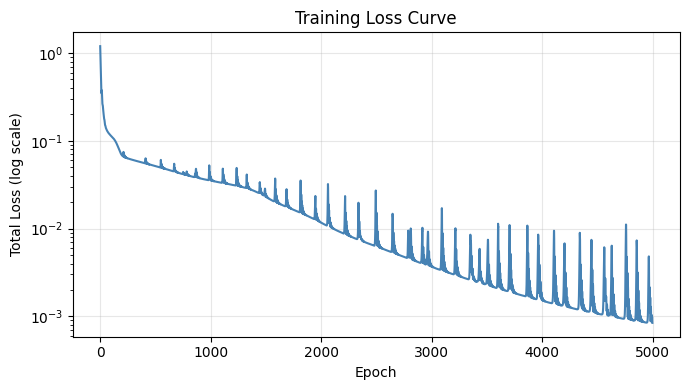


Plots saved to /mnt/user-data/outputs/


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyper-parameters ─────────────────────────────────────────────────────────
N_ic   = 50    # initial-condition points
N_bc   = 30    # boundary points
N_col  = 500   # collocation (PDE) points
EPOCHS = 5000
LR     = 1e-3

# ── Neural Network ───────────────────────────────────────────────────────────
class PINN(nn.Module):
    """Outputs [u, v] = [Re(h), Im(h)]"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 2)          # output: [u, v]
        )

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)           # shape (N, 2)

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ── Helper to compute gradients ───────────────────────────────────────────────
def grad(y, x):
    return torch.autograd.grad(y, x,
                               grad_outputs=torch.ones_like(y),
                               create_graph=True)[0]

# ── Training data ─────────────────────────────────────────────────────────────

# 1) Initial condition  h(0, x) = 2*sech(x)  →  u=2sech(x), v=0
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-5, 5).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic_true = 2.0 / torch.cosh(x_ic)          # Re(h)
v_ic_true = torch.zeros_like(x_ic)           # Im(h)

# 2) Periodic boundary h(t,-5)=h(t,5)
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, np.pi / 2).to(device)
x_left  = -5 * torch.ones(N_bc, 1).to(device)
x_right =  5 * torch.ones(N_bc, 1).to(device)

# 3) Collocation points inside domain
x_col = torch.FloatTensor(N_col, 1).uniform_(-5, 5).to(device).requires_grad_(True)
t_col = torch.FloatTensor(N_col, 1).uniform_(0, np.pi / 2).to(device).requires_grad_(True)

# ── Loss function ─────────────────────────────────────────────────────────────
def compute_loss():
    # --- IC loss ---
    uv_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((uv_ic[:, 0:1] - u_ic_true) ** 2 +
                         (uv_ic[:, 1:2] - v_ic_true) ** 2)

    # --- Periodic BC loss ---
    uv_l = model(x_left,  t_bc)
    uv_r = model(x_right, t_bc)
    loss_bc = torch.mean((uv_l - uv_r) ** 2)

    # --- PDE residual loss ---
    uv = model(x_col, t_col)
    u, v = uv[:, 0:1], uv[:, 1:2]

    u_t  = grad(u, t_col);  v_t  = grad(v, t_col)
    u_x  = grad(u, x_col);  v_x  = grad(v, x_col)
    u_xx = grad(u_x, x_col); v_xx = grad(v_x, x_col)

    h2 = u ** 2 + v ** 2          # |h|^2

    # i*h_t + 0.5*h_xx + |h|^2*h = 0
    # Real part: -v_t + 0.5*u_xx + h2*u = 0
    # Imag part:  u_t + 0.5*v_xx + h2*v = 0
    f_u = -v_t + 0.5 * u_xx + h2 * u
    f_v =  u_t + 0.5 * v_xx + h2 * v

    loss_pde = torch.mean(f_u ** 2 + f_v ** 2)

    return loss_ic + loss_bc + loss_pde, loss_ic, loss_bc, loss_pde

# ── Training loop ─────────────────────────────────────────────────────────────
loss_history = []
print(f"\nTraining for {EPOCHS} epochs ...\n")

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    loss, l_ic, l_bc, l_pde = compute_loss()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if epoch % 500 == 0 or epoch == 1:
        print(f"Epoch {epoch:5d} | Total={loss.item():.4e} | "
              f"IC={l_ic.item():.4e} | BC={l_bc.item():.4e} | PDE={l_pde.item():.4e}")

print("\nTraining complete!")

# Ensure output directory exists
#output_dir = "/mnt/user-data/outputs/"
#os.makedirs(output_dir, exist_ok=True)

# ── Prediction & Exact solution ───────────────────────────────────────────────
x_test = np.linspace(-5, 5, 256)

# Exact |h(t,x)| = 2*sech(x) * exp(i*t)  →  |h| = 2/cosh(x)  (constant envelope)
def exact_h(t_val, x_arr):
    return 2.0 / np.cosh(x_arr)          # amplitude independent of t

t_vals = [0.0, np.pi / 4, np.pi / 2]    # three time slices

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle("PINN – Nonlinear Schrödinger Equation\n|h(t,x)|: Exact vs Predicted",
             fontsize=13, fontweight="bold")

model.eval()
with torch.no_grad():
    for ax, t_val in zip(axes, t_vals):
        x_t = torch.FloatTensor(x_test[:, None]).to(device)
        t_t = t_val * torch.ones_like(x_t)
        uv  = model(x_t, t_t).cpu().numpy()
        h_pred = np.sqrt(uv[:, 0] ** 2 + uv[:, 1] ** 2)
        h_exact = exact_h(t_val, x_test)

        ax.plot(x_test, h_exact, "b-",  lw=2.5, label="Exact")
        ax.plot(x_test, h_pred,  "r--", lw=2,   label="Predicted")
        ax.set_title(f"t = {t_val:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("|h(t,x)|")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-5, 5)

plt.tight_layout()
#plt.savefig(os.path.join(output_dir, "pinn_results.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Loss curve ────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.semilogy(loss_history, color="steelblue", lw=1.5)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Total Loss (log scale)")
ax2.set_title("Training Loss Curve")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig(os.path.join(output_dir, "loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nPlots saved to /mnt/user-data/outputs/")